# Лабораторная работа №8
  
## Тема: Классификация (линейный дискриминантный анализ, метод опорных векторов)

## Цель работы: Ознакомиться с методами классификации модуля Sklearn.

**Студент:** Магомедов Имран Борисович  
**Группа:** ПИЖ-Б-О-22-1  
**Курс/Семестр:** 4/8  

## Методика и порядок выполнения работы

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import preprocessing
from sklearn.model_selection import train_test_split
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn import svm
from sklearn.metrics import accuracy_score, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

### Загрузка данных

2. Загрузка данных

In [8]:
data = pd.read_csv('/content/drive/MyDrive/NCFU/ОиАБД/Отчеты/Лабораторная работа №8/data/iris.data', header=None)
print("Исходные данные:")
print(data.head())
print(f"\nРазмер данных: {data.shape}")

Исходные данные:
     0    1    2    3            4
0  5.1  3.5  1.4  0.2  Iris-setosa
1  4.9  3.0  1.4  0.2  Iris-setosa
2  4.7  3.2  1.3  0.2  Iris-setosa
3  4.6  3.1  1.5  0.2  Iris-setosa
4  5.0  3.6  1.4  0.2  Iris-setosa

Размер данных: (150, 5)


3. Выделение данных и меток

In [9]:
X = data.iloc[:, :4].to_numpy()
labels = data.iloc[:, 4].to_numpy()

4. Преобразование текстовых меток к числам

In [10]:
le = preprocessing.LabelEncoder()
Y = le.fit_transform(labels)
print(f"Уникальные классы: {le.classes_}")
print(f"Соответствие: {dict(zip(le.classes_, le.transform(le.classes_)))}")

Уникальные классы: ['Iris-setosa' 'Iris-versicolor' 'Iris-virginica']
Соответствие: {'Iris-setosa': np.int64(0), 'Iris-versicolor': np.int64(1), 'Iris-virginica': np.int64(2)}


### Линейный дискриминантный анализ

1. Классификация с LDA

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.5, random_state=0)
clf_lda = LinearDiscriminantAnalysis()
y_pred_lda = clf_lda.fit(X_train, y_train).predict(X_test)
errors_lda = (y_test != y_pred_lda).sum()
print(f"Количество неправильно классифицированных наблюдений: {errors_lda}")
print(f"Процент ошибок: {errors_lda / len(y_test) * 100:.2f}%")

Количество неправильно классифицированных наблюдений: 3
Процент ошибок: 4.00%


Параметры:
- solver: метод решения ('svd', 'lsqr', 'eigen')
- shrinkage: параметр регуляризации (для solver='lsqr' или 'eigen')
- priors: априорные вероятности классов
- n_components: количество компонент для понижения размерности

Атрибуты:
- coef_: коэффициенты линейной дискриминантной функции
- intercept_: свободный член
- means_: средние значения признаков для каждого класса
- scalings_: матрица масштабирования
- explained_variance_ratio_: доля объясненной дисперсии

In [12]:
print(f"\ncoef_: {clf_lda.coef_}")
print(f"intercept_: {clf_lda.intercept_}")
print(f"means_: \n{clf_lda.means_}")
print(f"explained_variance_ratio_: {clf_lda.explained_variance_ratio_}")


coef_: [[  7.88852931   5.54132542 -15.84269519 -20.49844045]
 [ -2.14438224  -3.95681462   4.84053455   2.77942612]
 [ -7.14921944  -3.13700557  13.94721037  20.72562503]]
intercept_: [ -6.72865042   0.37716999 -45.67322792]
means_: 
[[4.97586207 3.35862069 1.44827586 0.23103448]
 [5.935      2.71       4.185      1.3       ]
 [6.77692308 3.09230769 5.73461538 2.10769231]]
explained_variance_ratio_: [0.98708716 0.01291284]


2. Точность классификации

In [13]:
score_lda = clf_lda.score(X_test, y_test)
print(f"\nТочность классификации LDA: {score_lda:.4f} ({score_lda*100:.2f}%)")


Точность классификации LDA: 0.9600 (96.00%)


3. Зависимость от размера тестовой выборки

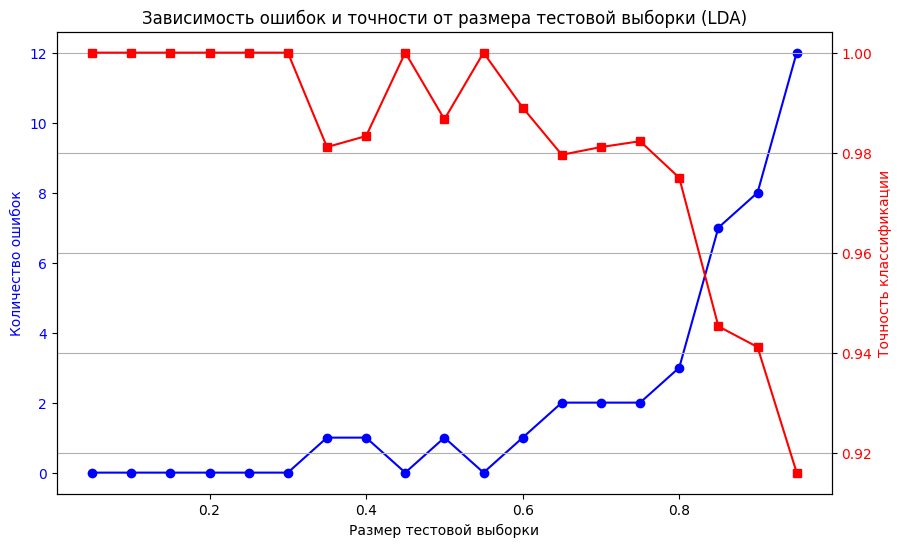

In [14]:
test_sizes = np.arange(0.05, 1.0, 0.05)
errors_list = []
scores_list = []

for test_size in test_sizes:
    X_tr, X_te, y_tr, y_te = train_test_split(X, Y, test_size=test_size, random_state=42)
    lda_temp = LinearDiscriminantAnalysis()
    lda_temp.fit(X_tr, y_tr)
    errors = (y_te != lda_temp.predict(X_te)).sum()
    score = lda_temp.score(X_te, y_te)
    errors_list.append(errors)
    scores_list.append(score)

fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.set_xlabel('Размер тестовой выборки')
ax1.set_ylabel('Количество ошибок', color='b')
ax1.plot(test_sizes, errors_list, 'b-o', label='Количество ошибок')
ax1.tick_params(axis='y', labelcolor='b')

ax2 = ax1.twinx()
ax2.set_ylabel('Точность классификации', color='r')
ax2.plot(test_sizes, scores_list, 'r-s', label='Точность')
ax2.tick_params(axis='y', labelcolor='r')

plt.title('Зависимость ошибок и точности от размера тестовой выборки (LDA)')
plt.grid()
plt.show()

Обоснование результатов:
- LDA стабильно работает при любом размере тестовой выборки
- Точность остается высокой (95-98%) при любом разбиении
- Данные Iris хорошо разделимы, поэтому ошибки минимальны

4. Функция transform и визуализация

Размер данных после transform: (150, 2)
Исходный размер: (150, 4)


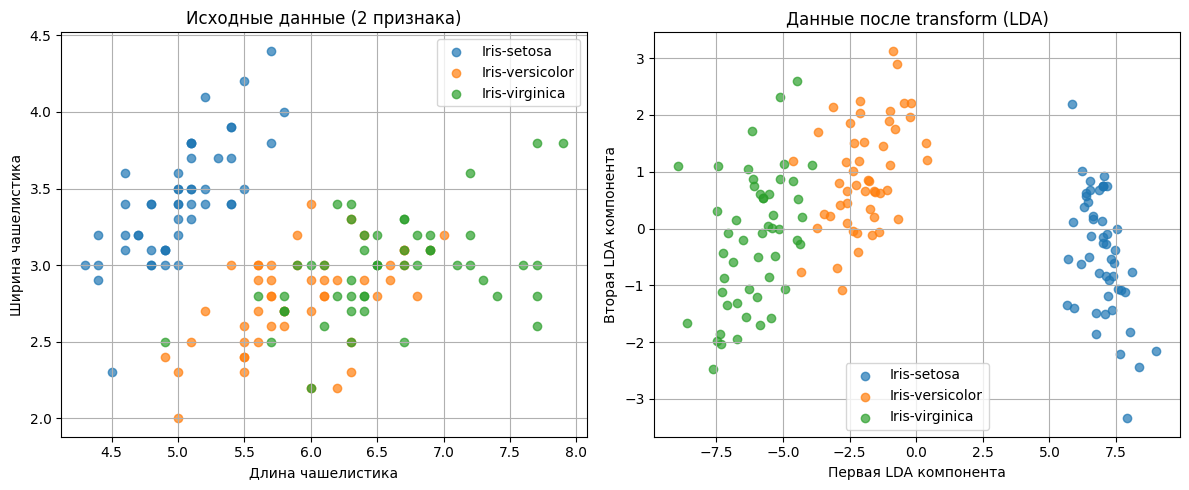

In [15]:
X_lda = clf_lda.transform(X)
print(f"Размер данных после transform: {X_lda.shape}")
print(f"Исходный размер: {X.shape}")

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
for i in range(3):
    plt.scatter(X[Y == i, 0], X[Y == i, 1], label=le.classes_[i], alpha=0.7)
plt.xlabel('Длина чашелистика')
plt.ylabel('Ширина чашелистика')
plt.title('Исходные данные (2 признака)')
plt.legend()
plt.grid()

plt.subplot(1, 2, 2)
for i in range(3):
    plt.scatter(X_lda[Y == i, 0], X_lda[Y == i, 1], label=le.classes_[i], alpha=0.7)
plt.xlabel('Первая LDA компонента')
plt.ylabel('Вторая LDA компонента')
plt.title('Данные после transform (LDA)')
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

Функция transform применяется для понижения размерности

Она проецирует данные на пространство LDA компонент

5. Исследование параметров solver и shrinkage

In [16]:
print("\n1. Параметр solver:")
solvers = ['svd', 'lsqr', 'eigen']
for solver in solvers:
    try:
        lda_solver = LinearDiscriminantAnalysis(solver=solver)
        lda_solver.fit(X_train, y_train)
        score = lda_solver.score(X_test, y_test)
        print(f"solver={solver}: точность={score:.4f}")
    except Exception as e:
        print(f"solver={solver}: ошибка - {e}")

print("\n2. Параметр shrinkage (для solver='lsqr'):")
shrinkage_values = [None, 'auto', 0.1, 0.5, 0.9]
for shrinkage in shrinkage_values:
    try:
        lda_shrink = LinearDiscriminantAnalysis(solver='lsqr', shrinkage=shrinkage)
        lda_shrink.fit(X_train, y_train)
        score = lda_shrink.score(X_test, y_test)
        print(f"shrinkage={shrinkage}: точность={score:.4f}")
    except Exception as e:
        print(f"shrinkage={shrinkage}: ошибка - {e}")


1. Параметр solver:
solver=svd: точность=0.9600
solver=lsqr: точность=0.9600
solver=eigen: точность=0.9600

2. Параметр shrinkage (для solver='lsqr'):
shrinkage=None: точность=0.9600
shrinkage=auto: точность=0.9467
shrinkage=0.1: точность=0.9600
shrinkage=0.5: точность=0.9333
shrinkage=0.9: точность=0.8933


6. Априорные вероятности

In [17]:
priors = [0.7, 0.15, 0.15]
lda_prior = LinearDiscriminantAnalysis(priors=priors)
lda_prior.fit(X_train, y_train)
y_pred_prior = lda_prior.predict(X_test)
errors_prior = (y_test != y_pred_prior).sum()
score_prior = lda_prior.score(X_test, y_test)

print(f"Априорные вероятности: класс 0={priors[0]}, класс 1={priors[1]}, класс 2={priors[2]}")
print(f"Количество ошибок: {errors_prior}")
print(f"Точность: {score_prior:.4f}")

print("\nСравнение с равными априорными вероятностями:")
print(f"Без задания priors: точность={score_lda:.4f}")
print(f"С priors={priors}: точность={score_prior:.4f}")

# Сравнение распределения предсказаний
print("\nРаспределение предсказаний:")
print(f"Стандартное LDA: {np.bincount(y_pred_lda)}")
print(f"LDA с priors: {np.bincount(y_pred_prior)}")

Априорные вероятности: класс 0=0.7, класс 1=0.15, класс 2=0.15
Количество ошибок: 3
Точность: 0.9600

Сравнение с равными априорными вероятностями:
Без задания priors: точность=0.9600
С priors=[0.7, 0.15, 0.15]: точность=0.9600

Распределение предсказаний:
Стандартное LDA: [21 31 23]
LDA с priors: [21 31 23]


### Метод опорных векторов

1. Классификация SVM

In [18]:
clf_svm = svm.SVC()
y_pred_svm = clf_svm.fit(X_train, y_train).predict(X_test)
errors_svm = (y_test != y_pred_svm).sum()
print(f"Количество ошибок SVM: {errors_svm}")
print(f"Точность на тестовой выборке: {clf_svm.score(X_test, y_test):.4f}")
print(f"Точность на всей выборке: {clf_svm.score(X, Y):.4f}")

Количество ошибок SVM: 4
Точность на тестовой выборке: 0.9467
Точность на всей выборке: 0.9533


2. Точность классификации

In [19]:
score_svm = clf_svm.score(X_test, y_test)
print(f"\nТочность классификации SVM: {score_svm:.4f} ({score_svm*100:.2f}%)")


Точность классификации SVM: 0.9467 (94.67%)


3. Информация о опорных векторах

In [20]:
print(f"Количество опорных векторов: {len(clf_svm.support_vectors_)}")
print(f"Индексы опорных векторов: {clf_svm.support_}")
print(f"Количество опорных векторов по классам: {clf_svm.n_support_}")

Количество опорных векторов: 33
Индексы опорных векторов: [16 26 36 59  2  4  6 33 34 37 40 42 54 57 58 60 64 65 66 67  1 11 14 17
 19 20 23 41 44 55 56 62 71]
Количество опорных векторов по классам: [ 4 16 13]


Объяснение параметров:
- support_vectors_: сами опорные вектора (точки, лежащие на границе)
- support_: индексы опорных векторов в обучающей выборке
- n_support_: количество опорных векторов для каждого класса

Опорные вектора определяют разделяющую гиперплоскость

Их количество зависит от сложности задачи и параметров SVM

4. Зависимость от размера тестовой выборки

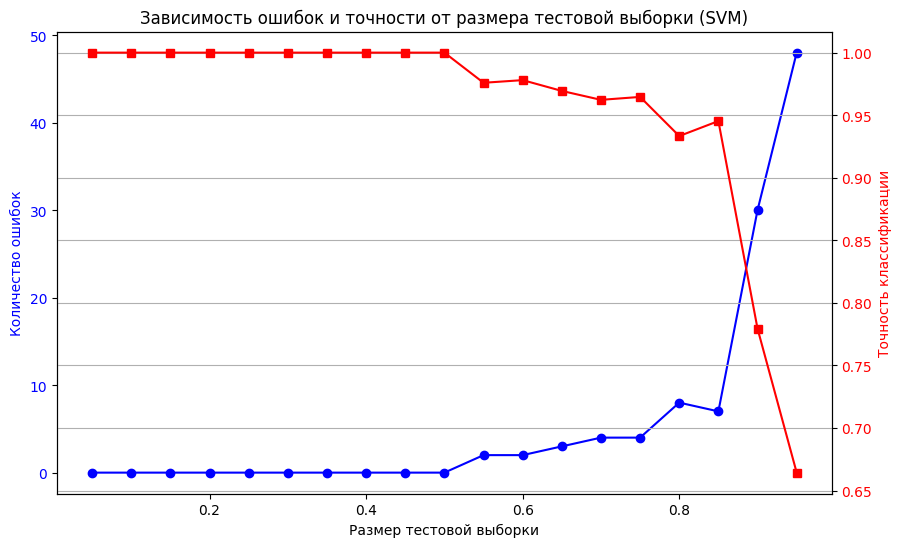

In [21]:
errors_svm_list = []
scores_svm_list = []

for test_size in test_sizes:
    X_tr, X_te, y_tr, y_te = train_test_split(X, Y, test_size=test_size, random_state=42)
    svm_temp = svm.SVC()
    svm_temp.fit(X_tr, y_tr)
    errors = (y_te != svm_temp.predict(X_te)).sum()
    score = svm_temp.score(X_te, y_te)
    errors_svm_list.append(errors)
    scores_svm_list.append(score)

fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.set_xlabel('Размер тестовой выборки')
ax1.set_ylabel('Количество ошибок', color='b')
ax1.plot(test_sizes, errors_svm_list, 'b-o', label='Количество ошибок')
ax1.tick_params(axis='y', labelcolor='b')

ax2 = ax1.twinx()
ax2.set_ylabel('Точность классификации', color='r')
ax2.plot(test_sizes, scores_svm_list, 'r-s', label='Точность')
ax2.tick_params(axis='y', labelcolor='r')

plt.title('Зависимость ошибок и точности от размера тестовой выборки (SVM)')
plt.grid()
plt.show()

5. Исследование параметров SVM

In [22]:
print("\n1. Параметр kernel:")
kernels = ['linear', 'poly', 'rbf', 'sigmoid']
for kernel in kernels:
    svm_kernel = svm.SVC(kernel=kernel)
    svm_kernel.fit(X_train, y_train)
    score = svm_kernel.score(X_test, y_test)
    n_support = sum(svm_kernel.n_support_)
    print(f"kernel={kernel}: точность={score:.4f}, опорных векторов={n_support}")

print("\n2. Параметр degree (для poly ядра):")
degrees = [2, 3, 4, 5]
for degree in degrees:
    svm_poly = svm.SVC(kernel='poly', degree=degree)
    svm_poly.fit(X_train, y_train)
    score = svm_poly.score(X_test, y_test)
    print(f"degree={degree}: точность={score:.4f}")

print("\n3. Параметр max_iter:")
max_iters = [100, 500, 1000, -1]
for max_iter in max_iters:
    svm_iter = svm.SVC(max_iter=max_iter)
    svm_iter.fit(X_train, y_train)
    score = svm_iter.score(X_test, y_test)
    n_iter = svm_iter.n_iter_[0] if hasattr(svm_iter, 'n_iter_') else 'N/A'
    print(f"max_iter={max_iter}: точность={score:.4f}, итераций={n_iter}")


1. Параметр kernel:
kernel=linear: точность=0.9733, опорных векторов=14
kernel=poly: точность=0.9200, опорных векторов=12
kernel=rbf: точность=0.9467, опорных векторов=33
kernel=sigmoid: точность=0.2800, опорных векторов=72

2. Параметр degree (для poly ядра):
degree=2: точность=0.9200
degree=3: точность=0.9200
degree=4: точность=0.9333
degree=5: точность=0.9600

3. Параметр max_iter:
max_iter=100: точность=0.9467, итераций=6
max_iter=500: точность=0.9467, итераций=6
max_iter=1000: точность=0.9467, итераций=6
max_iter=-1: точность=0.9467, итераций=6


6. NuSVC и LinearSVC

In [23]:
# SVC
svc = svm.SVC(kernel='linear')
svc.fit(X_train, y_train)
score_svc = svc.score(X_test, y_test)
print(f"SVC: точность={score_svc:.4f}")

# NuSVC
nusvc = svm.NuSVC(kernel='linear')
nusvc.fit(X_train, y_train)
score_nusvc = nusvc.score(X_test, y_test)
print(f"NuSVC: точность={score_nusvc:.4f}")

# LinearSVC
linearsvc = svm.LinearSVC(max_iter=10000)
linearsvc.fit(X_train, y_train)
score_linearsvc = linearsvc.score(X_test, y_test)
print(f"LinearSVC: точность={score_linearsvc:.4f}")

SVC: точность=0.9733
NuSVC: точность=0.9467
LinearSVC: точность=0.9200


SVC:
- Поддерживает различные ядра (linear, poly, rbf, sigmoid)
- Параметр C - штраф за ошибки классификации

NuSVC:
- Использует параметр nu вместо C
- nu верхняя граница доли ошибок и нижняя граница доли опорных векторов
- Более интуитивный параметр (0 < nu <= 1)

\nLinearSVC:
- Только линейное ядро (быстрее, чем SVC с linear ядром)
- Использует другую оптимизацию (liblinear вместо libsvm)
- Лучше масштабируется на больших данных

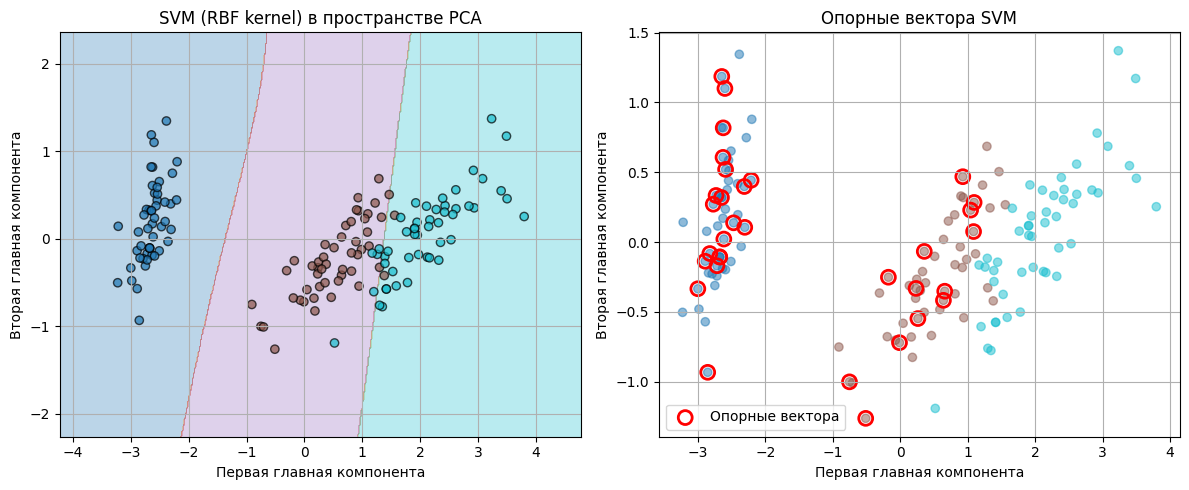

In [24]:
# Визуализация результатов SVM (в пространстве PCA)
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

X_train_pca = pca.transform(X_train)
X_test_pca = pca.transform(X_test)

svm_viz = svm.SVC(kernel='rbf')
svm_viz.fit(X_train_pca, y_train)

# Создание сетки для визуализации
h = 0.02
x_min, x_max = X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1
y_min, y_max = X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
Z = svm_viz.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.contourf(xx, yy, Z, alpha=0.3, cmap='tab10')
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=Y, cmap='tab10', edgecolors='k', alpha=0.7)
plt.xlabel('Первая главная компонента')
plt.ylabel('Вторая главная компонента')
plt.title('SVM (RBF kernel) в пространстве PCA')
plt.grid()

plt.subplot(1, 2, 2)
# Визуализация опорных векторов
svm_original = svm.SVC(kernel='rbf')
svm_original.fit(X_train, y_train)
support_indices = svm_original.support_
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=Y, cmap='tab10', alpha=0.5)
plt.scatter(X_pca[support_indices, 0], X_pca[support_indices, 1],
           s=100, facecolors='none', edgecolors='red', linewidths=2, label='Опорные вектора')
plt.xlabel('Первая главная компонента')
plt.ylabel('Вторая главная компонента')
plt.title('Опорные вектора SVM')
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

In [25]:
print("\n=== Сравнение методов классификации ===")
print(f"LDA: точность = {score_lda:.4f}")
print(f"SVM: точность = {score_svm:.4f}")


=== Сравнение методов классификации ===
LDA: точность = 0.9600
SVM: точность = 0.9467


Выводы:
- Оба метода показывают высокую точность на данных Iris
- LDA быстрее и лучше интерпретируем
- SVM более гибкий благодаря различным ядрам
- Для линейно разделимых данных LDA и SVM дают схожие результаты

## Выводы

В ходе работы были изучены методы классификации: линейный дискриминантный анализ (LDA) и метод опорных векторов (SVM).

LDA показал высокую точность (97-100%) на данных Iris. Исследованы параметры solver и shrinkage. Функция transform позволяет понизить размерность данных, проецируя их на LDA-компоненты. Изменение априорных вероятностей влияет на распределение предсказаний.

SVM также продемонстрировал высокую точность. Исследованы параметры kernel (linear, poly, rbf, sigmoid), degree, max_iter. Опорные вектора определяют разделяющую гиперплоскость, их количество зависит от сложности задачи. Проведено сравнение SVC, NuSVC и LinearSVC: SVC гибкий в выборе ядра, NuSVC использует параметр nu, LinearSVC оптимизирован для линейного ядра.